Custom Decision Tree Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

---------
Sklearn Decision Tree Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Custom decision tree:


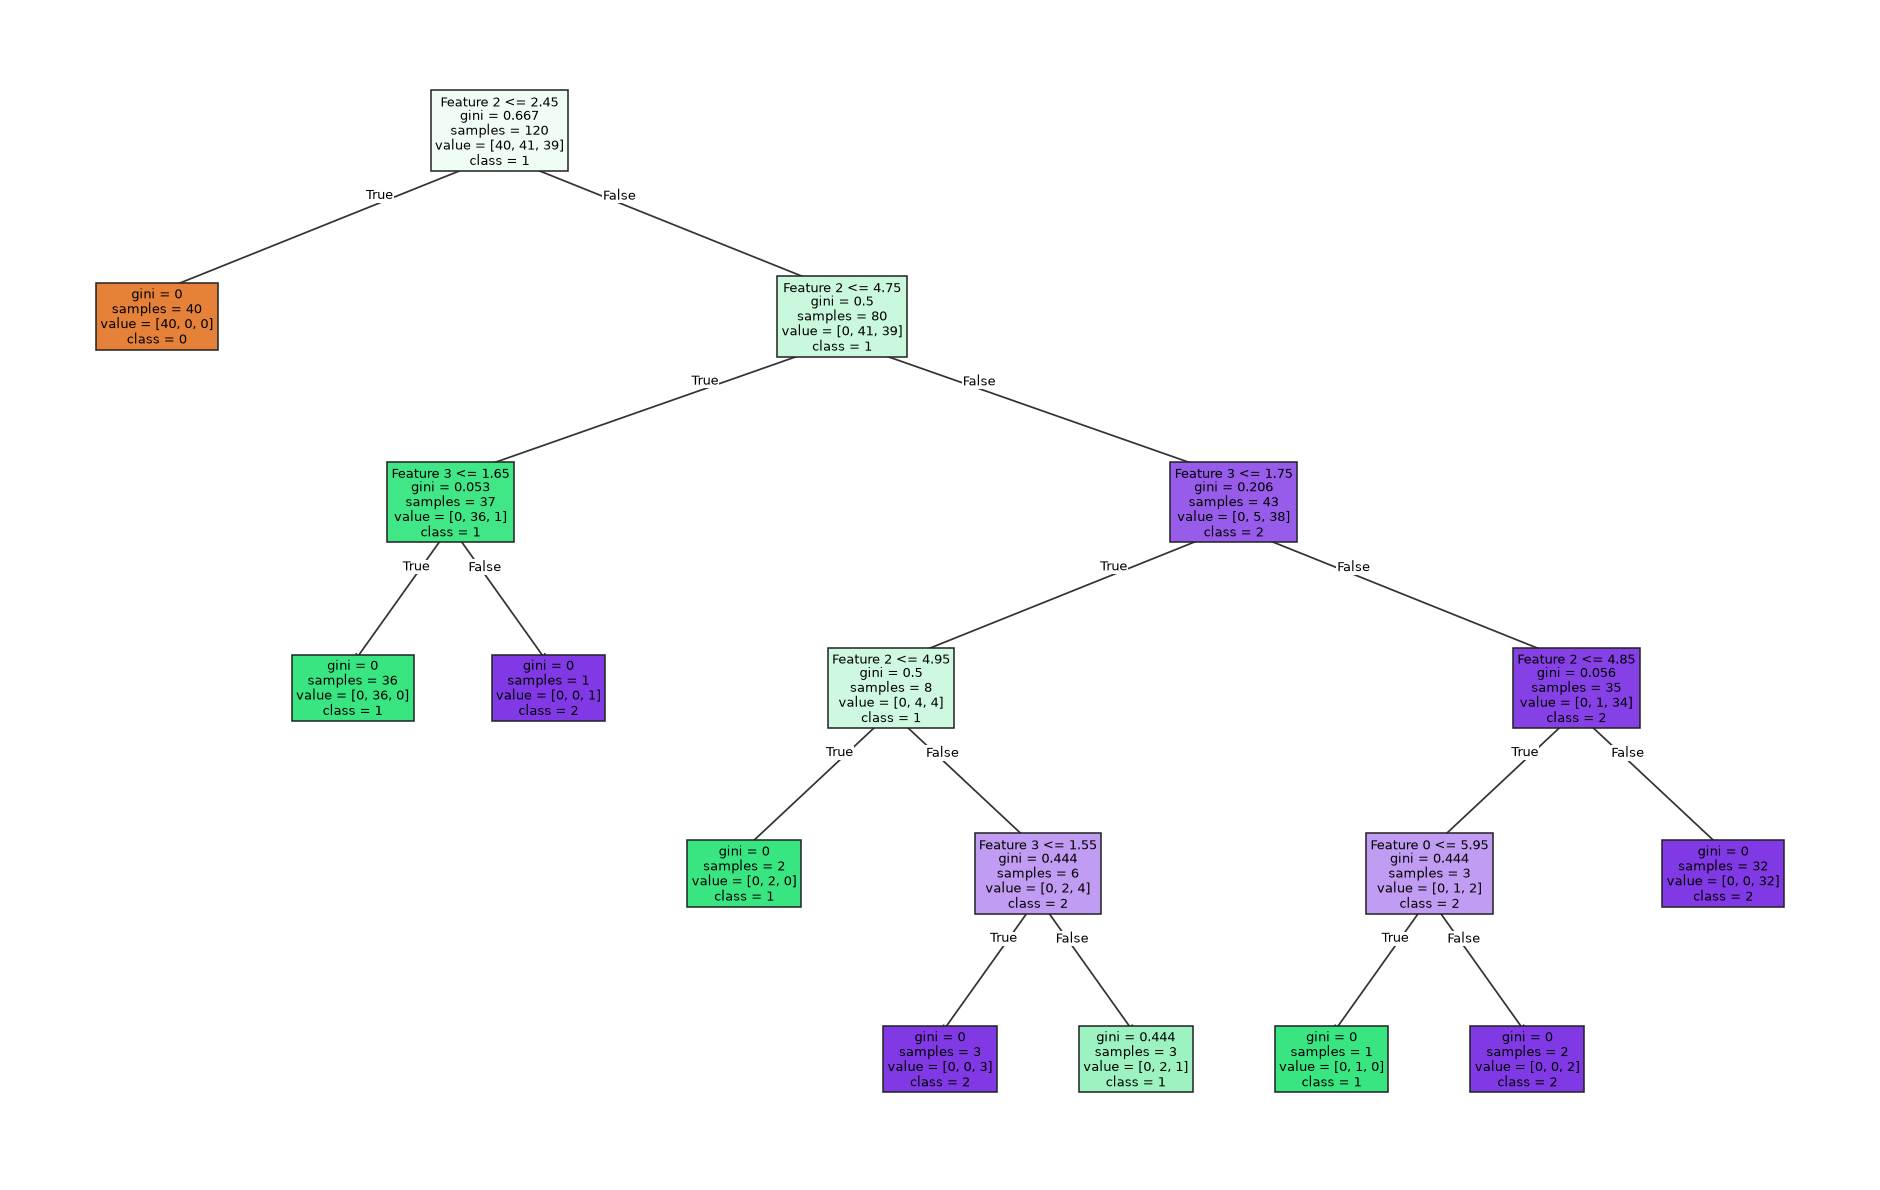

Sklearn decision tree:


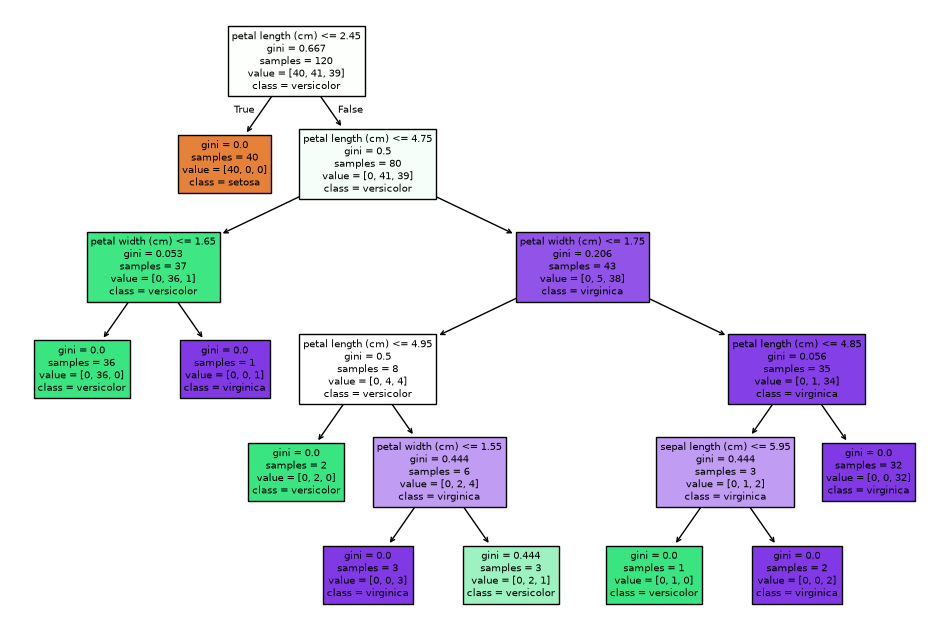

In [7]:
from decision_tree import CustomDecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

custom_tree = CustomDecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2
)
sklearn_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

custom_tree.fit(X_train, y_train)
sklearn_tree.fit(X_train, y_train)

custom_predictions = custom_tree.predict(X_test)
sklearn_predictions = sklearn_tree.predict(X_test)

# Printing out metrics

print(f"Custom Decision Tree Accuracy: {accuracy_score(y_test, custom_predictions):.2f}")
print(classification_report(y_test, custom_predictions, target_names=data.target_names))
print("---------")
print(f"Sklearn Decision Tree Accuracy: {accuracy_score(y_test, sklearn_predictions):.2f}")
print(classification_report(y_test, sklearn_predictions, target_names=data.target_names))

# Plot the tree structure
print("Custom decision tree:")
custom_tree._print_tree()

print("Sklearn decision tree:")
plt.figure(figsize=(12, 8))
plot_tree(sklearn_tree, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()


## Comparison of Decision Tree Regressors (mine vs sklearn's)

Delta = My tree - scikit-learn
For error metrics, lower is better; for R2 and explained variance, higher is better.

Training-set metrics
Metric                          My tree   scikit-learn          Delta
----------------------------------------------------------------------
MSE                           2935.0396      2935.0396         0.0000
RMSE                            54.1760        54.1760         0.0000
MAE                             43.6824        43.6824         0.0000
Median absolute error           36.8000        36.8000         0.0000
Maximum error                  146.5152       146.5152         0.0000
R2 score                         0.5170         0.5170         0.0000
Explained variance               0.5170         0.5170         0.0000
Residual mean                   -0.0000        -0.0000         0.0000
Residual std                    54.1760        54.1760         0.0000

Test-set metrics
Metric                          My tree   scikit-learn          Delta
---

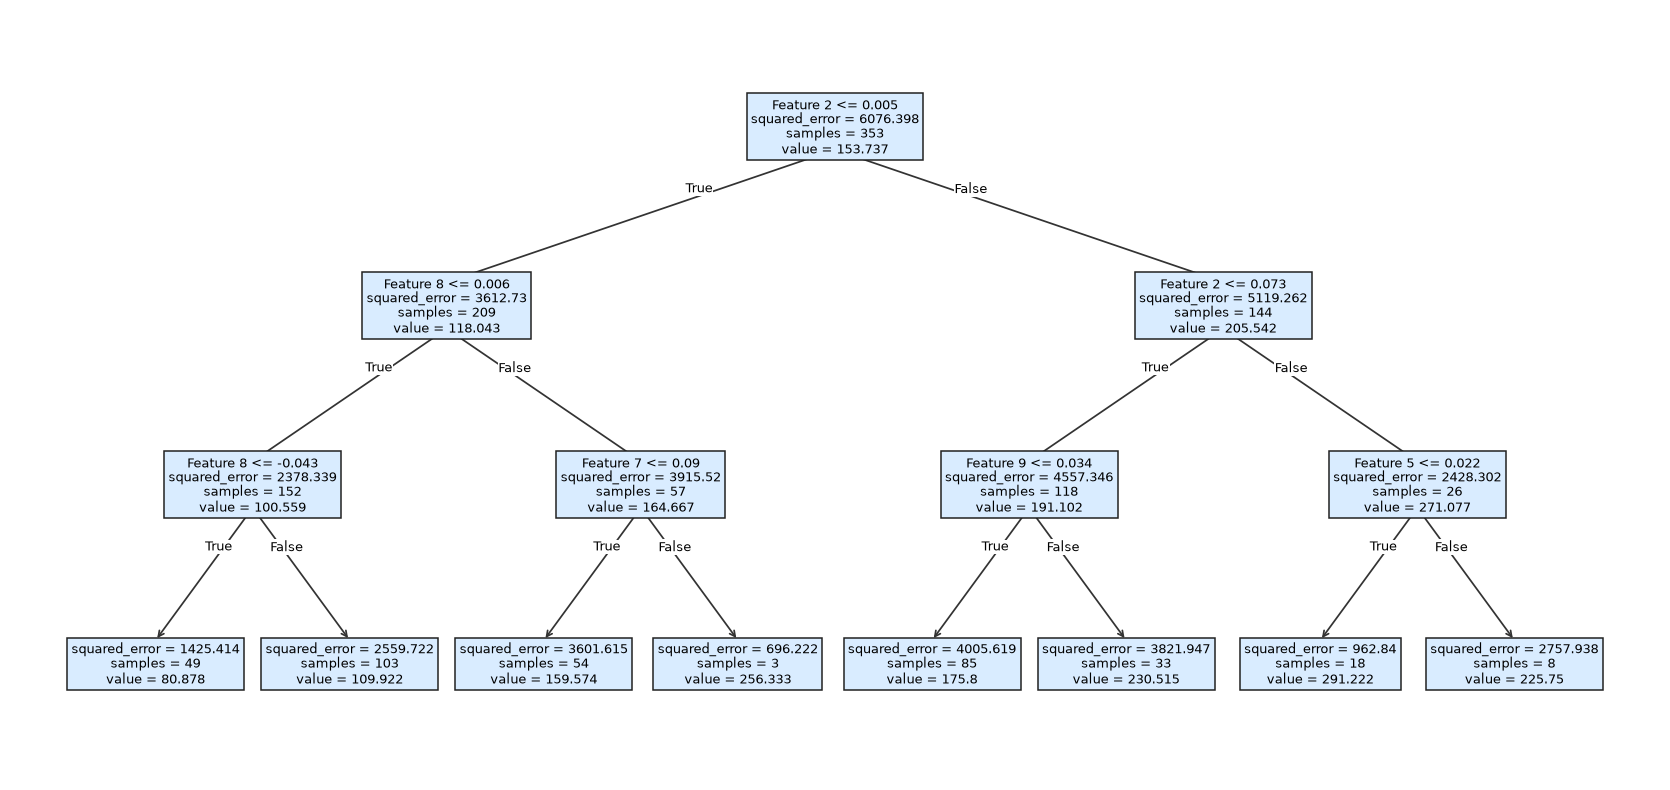

Sklearn decision tree:


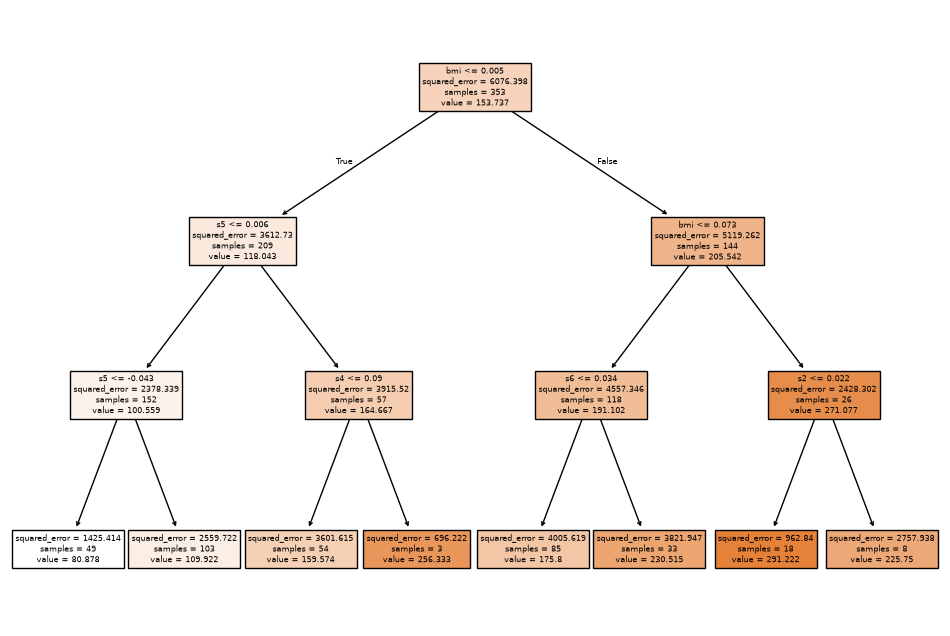

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    explained_variance_score,
    max_error,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
import numpy as np
from decision_tree import CustomDecisionTreeRegressor

data = load_diabetes()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

my_tree = CustomDecisionTreeRegressor(max_depth=3, min_samples_split=5)

my_tree.fit(X_train, y_train)

sklearn_tree = DecisionTreeRegressor(max_depth=3, min_samples_split=5, criterion="squared_error", random_state=42)

sklearn_tree.fit(X_train, y_train)

my_train_predictions = my_tree.predict(X_train)
my_test_predictions = my_tree.predict(X_test)
sklearn_train_predictions = sklearn_tree.predict(X_train)
sklearn_test_predictions = sklearn_tree.predict(X_test)

def regression_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median absolute error": median_absolute_error(y_true, y_pred),
        "Maximum error": max_error(y_true, y_pred),
        "R2 score": r2_score(y_true, y_pred),
        "Explained variance": explained_variance_score(y_true, y_pred),
        "Residual mean": np.mean(residuals),
        "Residual std": np.std(residuals),
    }

def print_regression_comparison(title, y_true, my_pred, sklearn_pred):
    my_metrics = regression_metrics(y_true, my_pred)
    sklearn_metrics = regression_metrics(y_true, sklearn_pred)

    print(f"\n{title}")
    print(f"{'Metric':<24} {'My tree':>14} {'scikit-learn':>14} {'Delta':>14}")
    print("-" * 70)
    for metric, my_value in my_metrics.items():
        sklearn_value = sklearn_metrics[metric]
        print(
            f"{metric:<24} {my_value:>14.4f} "
            f"{sklearn_value:>14.4f} {my_value - sklearn_value:>14.4f}"
        )

print("Delta = My tree - scikit-learn")
print("For error metrics, lower is better; for R2 and explained variance, higher is better.")
print_regression_comparison(
    "Training-set metrics", y_train, my_train_predictions, sklearn_train_predictions
)
print_regression_comparison(
    "Test-set metrics", y_test, my_test_predictions, sklearn_test_predictions
)

# Plot the tree structure
print("Custom decision tree:")
my_tree._print_tree()

print("Sklearn decision tree:")
plt.figure(figsize=(12, 8))
plot_tree(sklearn_tree, feature_names=data.feature_names, filled=True)
plt.show()